# Dimension Reduction Methods for Shooting Data Analysis

This notebook presents various dimension reduction and regularization approaches applied to shooting biomechanics data. Each method explores how mechanical features relate to shot outcomes across different shot types and locations.

### 1. Logistic Elastic Net Regression


Another method we used for feature selection is logistic elastic net regression. Elastic net combines L1 (lasso) and L2 (ridge) penalties, which allows it to shrink irrelevant coefficients to exactly zero while still handling groups of correlated predictors. This is a natural fit for our biomechanics data, where many variables are highly correlated with each other. The L1 component performs variable selection by zeroing out weak features, and the L2 component stabilizes estimates among correlated groups. To execute this, we used all numeric biomechanical predictors, excluding identifying and outcome-adjacent columns (Name, Date, PlayerID, Shot.X.Pos, Shot.Y.Pos, Shot.Distance). Made was the binary outcome variable. We stratified by shot location and shot type (off the dribble vs. catch and shoot), with free throws as their own group, and filtered to players with 20 or more shots per subset. Before fitting, we removed features correlated above |r| > 0.90, standardized the remaining predictors, and fit a logistic elastic net with 5-fold cross-validation optimizing ROC AUC across a grid of L1 ratios and penalty strengths for each group.

To check whether the selected features were reliable and not just artifacts of a single model fit, we ran a bootstrap stability analysis with 200 resamples per group. For each resample, we refit the elastic net using the same hyperparameters and tracked how often each top feature's coefficient was nonzero. Features that appeared nonzero in more than 80% of resamples were labeled "stable," between 50–80% "marginal," and below 50% "unstable." We then ranked features by how many groups they were stably selected in and whether their direction (positive toward making, negative toward missing) was consistent. Features that were bootstrap-stable across multiple groups with a consistent sign were considered the most trustworthy signals in the data.

Overall, similar to PLS, the predictive performance was modest—AUC values across groups generally fell in the 0.5–0.6 range, confirming that single-shot biomechanics alone are weak predictors of make/miss. However, the elastic net was more useful as a feature selection tool than as a predictive model. The bootstrap analysis helped us identify which biomechanical variables are most consistently associated with shot outcomes even when the overall effect sizes are small. Across subsets, commonly stable features included variables related to torso dynamics, stance gap, and shoulder flexion, though which specific features mattered varied by shot context. The main limitations are the same as with PLS: the overall signal is weak, and some subsets had limited sample sizes with only a few players, which likely limits the reliability of the selection. That said, the advantage of elastic net over PLS is interpretability—instead of latent components that need VIP scores to decode, we get direct coefficient estimates on individual features along with a clear measure of how reliable each selection is across resamples.

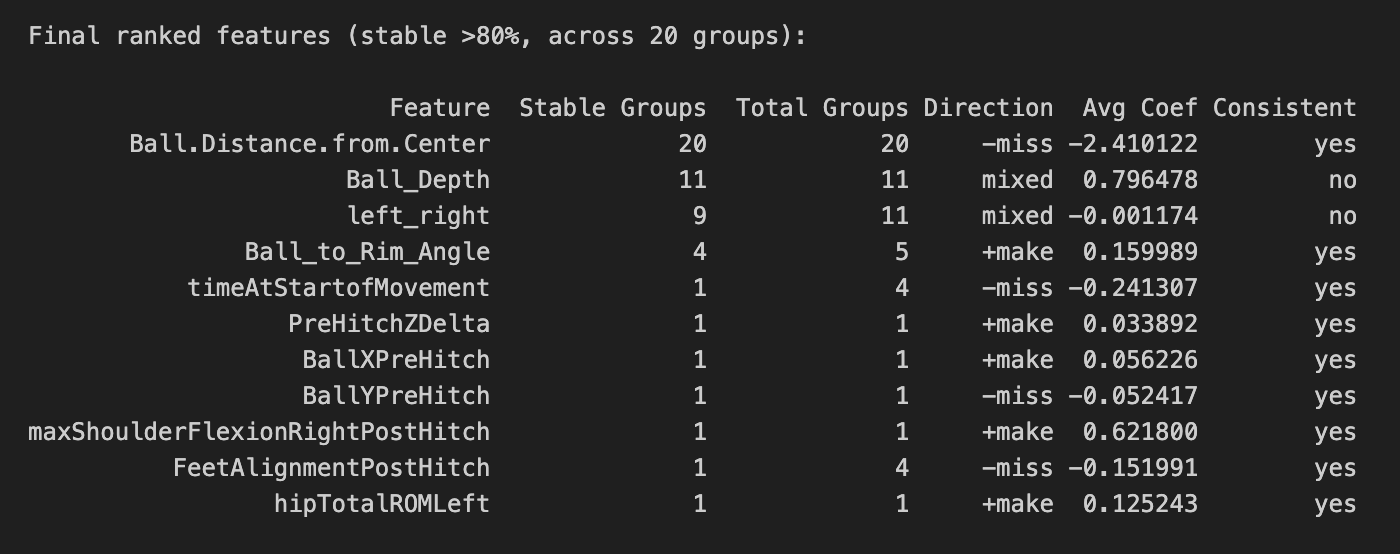


### 2. PLS (Partial Least Squares)

One of the methods we used for dimension reduction is PLS. PLS is a supervised dimension reduction which builds components to maximize covarience between predictors and the outcome. It is considered a "good fit" when there are many correlated variables (in our case biomechanics) since it compresses them into a small set of latent factors. We can explain the components with weights using VIP (Variable Importance in Projection) scores. In order to execute this, we essentially used all predictors except for ball_depth, playerID, and ball.distance.from.center, since those are identifying or outcome variables. Made was the outcome variable we set. we then stratified by each shot location. We also stratified by shot type - off the dribble or catch and shoot (besides free throws) - and filtered by keeping only players with greater than or equal to 20 shots in each subset. We attempted creating k = 10 and 20 components to see if there is a difference in ROC AUC for each respective subset.

We generally found that the overall predictive signal is weak. For k = 10, we found that the mean ROC AUC across all subsets was around 0.526, the median 0.524, min 0.423, and max 0.617. For k = 20, the mean ROC AUC was 0.516, median 0.520, min 0.412, and max was 0.597. Since a ROC AUC of 0.5 is essentially random chance, PLS resulted in essentially no predictive strength. Also, since the mean, median, min, and max were all pretty similar between k = 10 and k = 20, we can see that increasing components from 10 to 20 did not improve ROC AUC on average. One of our best performing subsets was the middle three, off the dribble with an ROC AUC of 0.616 with 10 components.

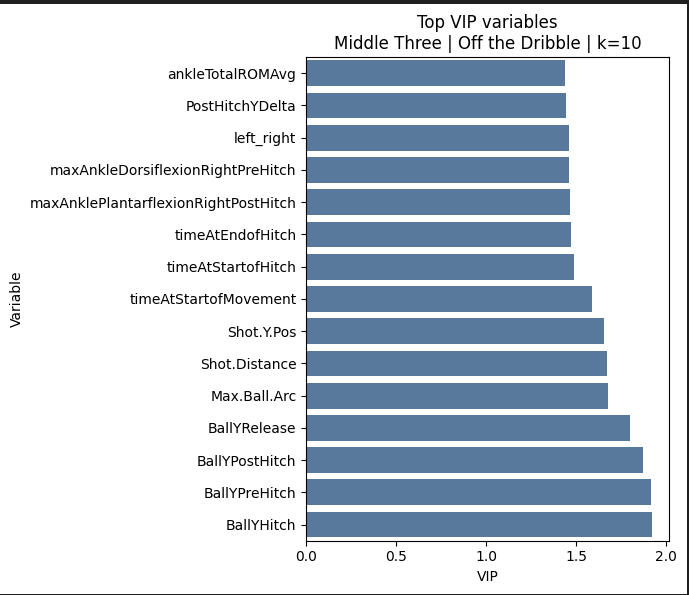

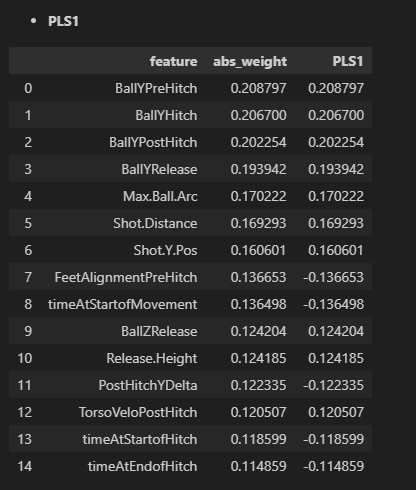

As we can see here, for middle threes, off the dribble specifically, BallYHitch and BallYPreHitch seems to be an important factor in making this shot. Across all subsets, the most influential variables were Shot.Distance, Shot.X.Pos, MaxStanceGapPostHitch, Max.Ball.Arc, and torso dynamics like TorsoVeloPostHitch. Even though we can get an indication of some influential variables, the main challange is that the signals for the reduction are generally weak. This can be due to a variety of reasons. One reason is that PLS particularly works well with linear data, and the dataset may not be linear. This means that other dimension reduction methods may be more efficient. Another reason is the data robustness. For some of the subsets, the sample included just a few players, which is likely not enough to execute strong dimension reduction. 

### 3. LASSO Regression


To identify the most important factors influencing shot success, we applied a LASSO (Least Absolute Shrinkage and Selection Operator) logistic regression approach. LASSO is a regularized regression technique that performs both prediction and variable selection by shrinking less important coefficients toward zero, effectively removing irrelevant predictors from the model. This makes it well-suited for datasets containing many biomechanical and ball-tracking features, where traditional regression would risk overfitting. The analysis was conducted separately by shot type and location to account for meaningful differences in shooting context. Only players with at least 20 shots from a given shot type and location were included to ensure reliable model estimates. Free throws were analyzed first, followed by middle three-point shots separated into catch-and-shoot and off-the-dribble attempts. To evaluate model generalizability, data were split into training and test sets, and cross-validated lambda values were used to determine the optimal level of regularization for each model. Model performance was assessed using ROC curves and AUC values computed on the held-out test set.

<img src="LassoImages/FreeThrow1.png" width="70%">

The LASSO model for free throws identified ball alignment as the dominant predictor of shot success. Ball.Distance.from.Center carried the largest negative coefficient in the model, indicating that shots with greater horizontal deviation from the center of the rim were substantially less likely to go in. PostHitchXDelta and Max.Ball.Arc emerged as the strongest positive predictors, suggesting that lateral ball movement through the shooting motion and a higher ball arc are associated with improved free throw outcomes. Biomechanical variables contributed relatively little explanatory power overall. Among those retained by the model, TorsoVeloRelease, BallVeloPostHitch, and MaxStanceGapPostHitch showed modest negative associations with success, while timeAtRelease showed a small positive effect. These results suggest that free throw success is driven primarily by precise ball positioning and trajectory rather than complex body mechanics, and that departures from ideal ball alignment are difficult to overcome through mechanical adjustments alone.

<img src="LassoImages/Catch&Shoot.png" width="70%">

For catch-and-shoot middle three-point attempts, the LASSO model retained a larger set of predictors, reflecting greater complexity in the shooting process relative to free throws. Ball.Distance.from.Center again carried the largest negative coefficient, reinforcing the critical importance of rim alignment regardless of shot type. Max.Ball.Released..Away.from.body. also showed a strong negative effect, suggesting that releasing the ball farther from the body is associated with reduced shot consistency in catch-and-shoot situations. MaxStanceGapPostHitch and BallYPostHitch were among the other negatively associated predictors, while Max.Ball.Arc, BallXPostHitch, Ball_Depth, timeAtStartofMovement, BallXRelease, and left_right showed positive associations with shot success. Compared to free throws, biomechanical variables played a more meaningful role in this model, particularly those related to upper-body positioning and ball entry location. These findings suggest that while ball alignment remains the primary driver of success, the mechanics of receiving and setting up for a catch-and-shoot attempt introduce additional variability that body positioning can meaningfully influence.

<img src="LassoImages/OffTheDribble.png" width="70%">

The off-the-dribble middle three model retained the largest number of predictors across all three shot types, consistent with the added mechanical complexity of creating a shot off the dribble. Starting.Ball.Height and Ball.Distance.from.Center carried the largest negative coefficients, indicating that shots beginning from lower ball positions or with greater lateral deviation from the rim were less likely to succeed. HitchXDelta, Release.Height, MaxStanceGapPreHitch, and PercTimePostHitch also showed notable negative associations, while timeAtStartofMovement and BallXHitch were the strongest positive predictors, along with Ball_Depth and maxAnkleDorsiflexionRightPreHitch. Compared to the catch-and-shoot model, the off-the-dribble model showed a broader distribution of meaningful biomechanical contributors, particularly those related to pre-hitch positioning and movement timing. This pattern suggests that shooting off the dribble places greater demands on body mechanics earlier in the shooting sequence, and that how a player initiates and structures the motion before the hitch plays an important role in determining shot outcomes.

<img src="LassoImages/ROCCurve.png" width="70%">

<img src="LassoImages/AUCValues.png" width="30%">

To evaluate the predictive accuracy of each LASSO model on unseen data, ROC curves were generated using the held-out test set, and AUC values were computed for each shot type. The AUC quantifies the model's ability to discriminate between made and missed shots across all possible classification thresholds, with values closer to 1.0 indicating stronger predictive performance and a value of 0.5 representing chance-level discrimination.

All three models demonstrated strong discriminative ability. The off-the-dribble middle three model achieved the highest AUC of 0.980, followed by the catch-and-shoot middle three model at 0.961, and the free throw model at 0.925. These results indicate that the LASSO-selected biomechanical and ball-tracking features are highly predictive of shot outcomes across all three shooting contexts. The relatively higher AUC for the off-the-dribble model may reflect greater variance in biomechanical patterns among off-the-dribble attempts, which provides the model with more discriminating information to separate successful from unsuccessful shots. Conversely, the slightly lower AUC for free throws is consistent with the more constrained and uniform mechanical environment of the free throw line, where differences between made and missed shots are more subtle and harder to detect. 

Taken together, the LASSO regression models and corresponding model performance metrics reveal several consistent patterns across shooting contexts. Ball alignment with the rim, captured most directly by Ball.Distance.from.Center, was the single most influential predictor of shot success in every model, underscoring that spatial accuracy in ball positioning is the primary determinant of shooting outcomes regardless of shot type. Ball trajectory variables, particularly Max.Ball.Arc and Ball_Depth, also appeared consistently as meaningful predictors, suggesting that arc and depth of the shot plane are important secondary factors across contexts.

The role of biomechanical variables was more context-dependent. Free throws showed minimal biomechanical contribution beyond ball control, while three-point shots, especially off-the-dribble attempts, incorporated a broader range of body mechanics as meaningful predictors. Variables related to stance width, torso velocity, hitch positioning, and movement timing all contributed to the three-point models, indicating that the mechanical demands of longer, more dynamic shots require greater coordination across the kinetic chain. These findings support the view that shooting mechanics do not follow a single universal template. Rather, optimal performance is reliant on shooting contexts.

### 4. Canonical Correlation Analysis (CCA)

### 5. Principal Component Logistic Regression (PCLR)